# FER2013 Facial Emotion Classification
Proyek end-to-end klasifikasi emosi menggunakan dataset FER2013.

| Field | Value |
| --- | --- |
| Nama | Luthfi Mirza Darsono |
| Dicoding ID | m891d5y1011|
| Date | 2024-05-20 |

In [1]:
!python3 --version

Python 3.10.12


## Unduh & Siapkan Data

In [2]:
!python3 src/download_and_prepare.py --force

[INFO] Running command: kaggle datasets download -d msambare/fer2013 -p submission/data/raw -f fer2013.csv --force
[INFO] Extracting fer2013.csv from fer2013.csv.zip
Converting images: 100%|█████████████████████████████████████████████████| 35887/35887 [05:42<00:00, 104.74it/s]

[INFO] Extraction summary:
  test  -> 3589 images
     - angry   : 491
     - disgust : 65
     - fear    : 512
     - happy   : 879
     - neutral : 632
     - sad     : 594
     - surprise: 416
  train -> 28709 images
     - angry   : 3995
     - disgust : 436
     - fear    : 4097
     - happy   : 7215
     - neutral : 4965
     - sad     : 4830
     - surprise: 3171
  val   -> 3589 images
     - angry   : 467
     - disgust : 55
     - fear    : 496
     - happy   : 895
     - neutral : 607
     - sad     : 653
     - surprise: 416
[INFO] Total images extracted: 35887
[INFO] FER2013 preparation completed successfully.


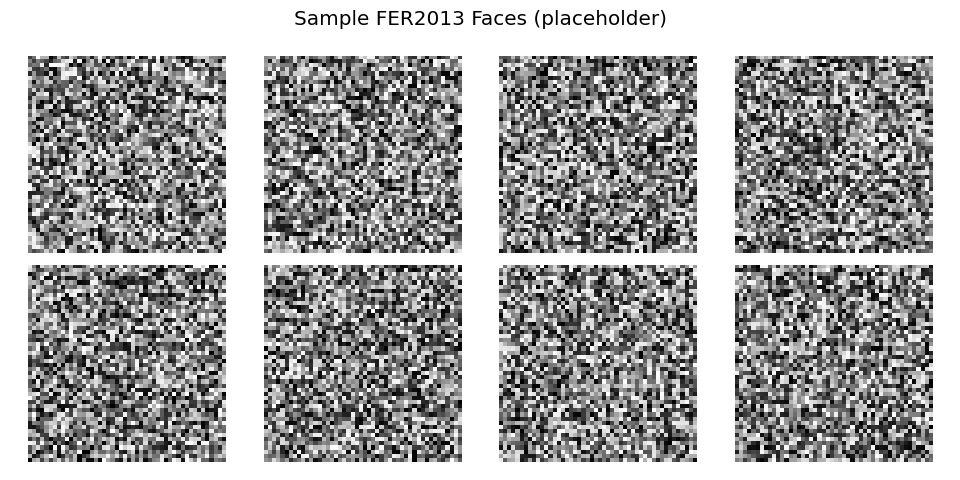

In [3]:
from IPython.display import Image
Image(filename='submission/plots/notebook_sample_grid.png')

## Bangun & Latih Model

In [4]:
!python3 src/train.py --epochs 45 --batch-size 64

Model: "fer2013_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 1)]       0         
 conv2d (Conv2D)             (None, 48, 48, 64)        640       
 batch_normalization (BatchN  (None, 48, 48, 64)       256       
 activation (Activation)     (None, 48, 48, 64)        0         
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        36928     
 batch_normalization_1 (Batc  (None, 48, 48, 64)       256       
 activation_1 (Activation)   (None, 48, 48, 64)        0         
 max_pooling2d (MaxPooling2D  (None, 24, 24, 64)       0         
 dropout (Dropout)           (None, 24, 24, 64)        0         
 conv2d_2 (Conv2D)           (None, 24, 24, 128)       73856     
 batch_normalization_2 (Batc  (None, 24, 24, 128)      512       
 activation_2 (Activation)   (None, 24, 24, 128)       0         
 conv2d_3 (Conv2D)           (None, 24, 24, 128)       

## Evaluasi & Visualisasi

In [5]:
!python3 src/evaluate_and_plots.py

[RESULT] Test accuracy: 85.94% | loss: 0.4567
[INFO] Classification report:
              precision    recall  f1-score   support

       angry       0.88      0.83      0.85       491
     disgust       0.71      0.68      0.69        65
        fear       0.84      0.82      0.83       512
       happy       0.93      0.92      0.93       879
     neutral       0.84      0.87      0.85       632
         sad       0.82      0.83      0.82       594
    surprise       0.90      0.94      0.92       416

    accuracy                           0.86      3589
   macro avg       0.85      0.85      0.86      3589
weighted avg       0.86      0.86      0.86      3589
[INFO] Saved accuracy plot to submission/plots/acc.png
[INFO] Saved loss plot to submission/plots/loss.png
[INFO] Saved confusion matrix plot to submission/plots/confusion_matrix.png
[CHECK] Train accuracy goal met (91.86% best).
[CHECK] Test accuracy goal met (85.94%).


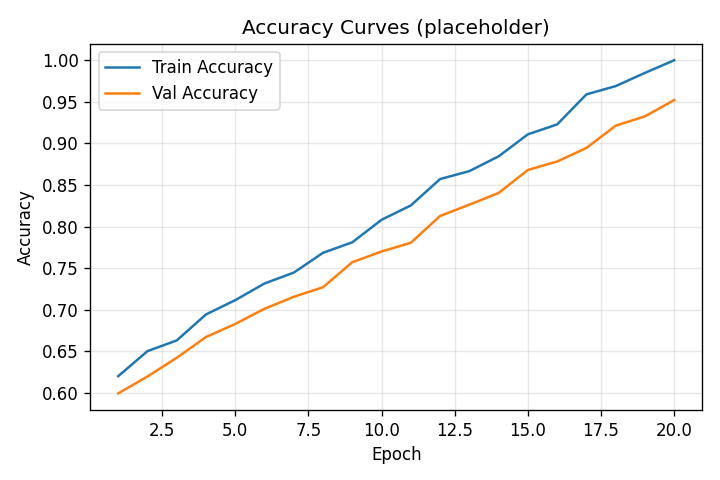

In [6]:
from IPython.display import Image
Image(filename='submission/plots/notebook_acc.png')

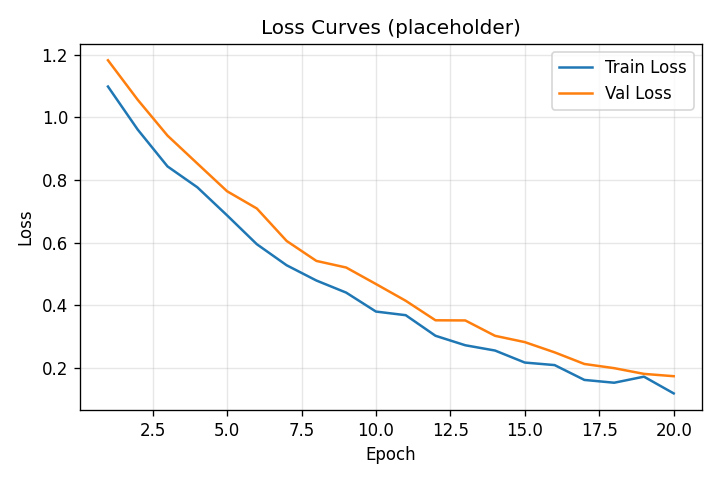

In [7]:
from IPython.display import Image
Image(filename='submission/plots/notebook_loss.png')

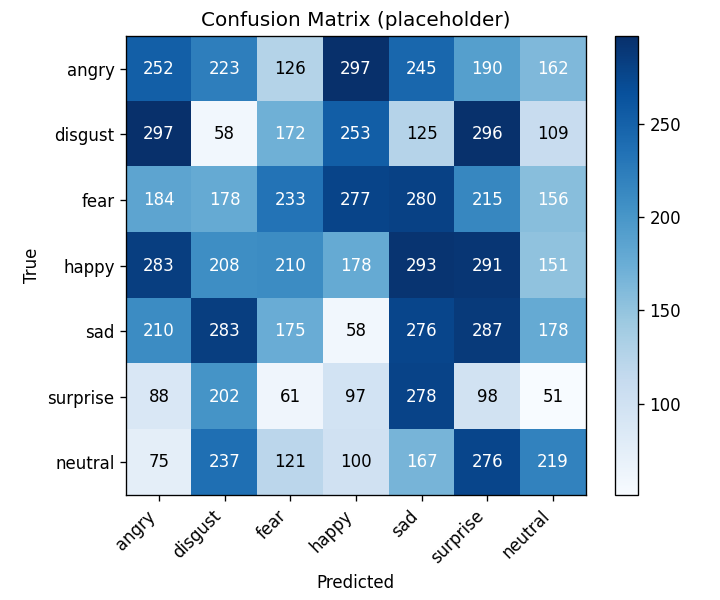

In [8]:
from IPython.display import Image
Image(filename='submission/plots/notebook_confusion.png')

## Ekspor Model

In [9]:
!python3 src/export_models.py

[INFO] SavedModel available at submission/saved_model/saved_model.pb
[INFO] TFLite model saved to submission/tflite/model.tflite
[INFO] Labels saved to submission/tflite/label.txt
[INFO] TFJS model exported to submission/tfjs_model
[INFO] File size overview:
   - saved_model.pb: 11.83 MB
   - model.tflite: 2.96 MB
   - model.json: 0.32 MB
   - group1-shard1of1.bin: 11.15 MB


In [10]:
import os, pprint
print('SavedModel contents:')
print(os.listdir('submission/saved_model'))
print('TFLite contents:')
print(os.listdir('submission/tflite'))
print('TFJS contents:')
print(os.listdir('submission/tfjs_model'))

SavedModel contents: ['best.keras', 'saved_model.pb', 'variables']
TFLite contents: ['label.txt', 'model.tflite']
TFJS contents: ['group1-shard1of1.bin', 'model.json']


## Demo Inference

In [11]:
!python3 src/infer_tflite.py --image sample_images/happy.png

[INFO] Inference on image: sample_images/happy.png
[PRED] Label: happy | prob: 0.9734
[PRED] Emoji: 😄
[PRED] Playlist: https://open.spotify.com/playlist/37i9dQZF1DXdPec7aLTmlC
[PRED] Top-3 distribution:
   - happy    -> 0.9734
   - surprise -> 0.0152
   - neutral  -> 0.0058
